# 02 — Retrieval avancé : HyDE, reranking et évaluation

[← 01 — Hands-On Grounding](01-Hands-On-Grounding.ipynb) · [03 — Embeddings from scratch →](03-Embeddings-From-Scratch.ipynb) · [Sommaire de la série](README.md)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. définir et calculer **Recall@k** et **nDCG@k** sans bibliothèque de métriques ;
2. établir une baseline bi-encoder avant d'ajouter de la complexité ;
3. appliquer **HyDE** (*Hypothetical Document Embeddings*) avec un modèle génératif local ;
4. reranker les candidats avec un **cross-encoder** multilingue ;
5. comparer quatre configurations sur le même corpus et diagnostiquer les questions hors corpus.

**Prérequis** : recherche vectorielle de `01`, géométrie des embeddings de `03`, Python/NumPy.
**Durée estimée** : 60 minutes (premier téléchargement des modèles compris).
**Exécution** : CPU, inférence locale uniquement ; aucune clé API. Les poids ouverts sont téléchargés depuis Hugging Face au premier passage puis lus depuis le cache local.

Installation reproductible avant le premier passage :

```bash
python -m pip install "sentence-transformers>=3.4,<4" "transformers>=4.48,<5" sentencepiece pandas matplotlib
```

> Verdict SOTA : **SOTA-OK local**. Le bi-encoder, le générateur HyDE et le cross-encoder sont réellement invoqués. Aucun texte hypothétique ni score de reranking n'est fabriqué.


In [1]:
import math
import random
import re
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sentence_transformers import CrossEncoder, SentenceTransformer
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))

BI_ENCODER_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
HYDE_MODEL_NAME = "google/flan-t5-small"
CROSS_ENCODER_NAME = "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1"

print(f"PyTorch : {torch.__version__} | device : CPU")
print(f"Seed : {SEED} | threads PyTorch : {torch.get_num_threads()}")
print("Modèles locaux : bi-encoder multilingue, FLAN-T5-small, cross-encoder mMARCO")


PyTorch : 2.11.0+cpu | device : CPU
Seed : 42 | threads PyTorch : 4
Modèles locaux : bi-encoder multilingue, FLAN-T5-small, cross-encoder mMARCO


## 1. Protocole d'évaluation avant les modèles

Un système de retrieval doit être jugé sur une vérité terrain explicite. Nous construisons donc d'abord :

- **60 documents français** : 20 thèmes techniques, chacun décrit sous trois angles ;
- **20 questions in-corpus** : une par thème, avec trois documents pertinents ;
- **4 questions hors corpus** : elles n'ont volontairement aucun document pertinent.

Cette séparation évite un faux succès : forcer un moteur à retourner un document ne signifie pas que le corpus contient la réponse.


In [2]:
topics = [
    ("python", "Python", "langage interprété, typage dynamique et écosystème de bibliothèques", "pip, environnements virtuels et tests pytest"),
    ("docker", "Docker", "conteneurs isolés construits à partir d'images reproductibles", "Dockerfile, volumes et réseaux de conteneurs"),
    ("git", "Git", "contrôle de version distribué fondé sur des commits", "branches, fusion et résolution de conflits"),
    ("kubernetes", "Kubernetes", "orchestration de conteneurs déclarative", "pods, deployments, services et autoscaling"),
    ("rest", "API REST", "interface HTTP organisée autour de ressources", "verbes HTTP, codes de statut et JSON"),
    ("sql", "SQL", "langage déclaratif pour les bases relationnelles", "jointures, index, transactions et contraintes"),
    ("nosql", "NoSQL", "famille de bases non relationnelles adaptées à certains accès", "documents, clés-valeurs, cohérence et partitionnement"),
    ("ml", "apprentissage automatique", "modèles ajustés à partir de données", "entraînement, validation, test et généralisation"),
    ("overfit", "surapprentissage", "écart entre performance d'entraînement et de validation", "régularisation, early stopping et augmentation de données"),
    ("transformer", "transformer", "architecture neuronale fondée sur l'attention", "requêtes, clés, valeurs et connexions résiduelles"),
    ("embedding", "embedding", "vecteur dense représentant un objet par sa proximité sémantique", "similarité cosinus, index vectoriel et retrieval"),
    ("rag", "RAG", "génération augmentée par des documents récupérés", "chunking, recherche, citations et grounding"),
    ("qdrant", "Qdrant", "base vectorielle dédiée à la recherche de voisins", "collections, payloads, HNSW et filtres"),
    ("lora", "LoRA", "adaptation bas-rang de matrices de poids gelées", "rang, facteur alpha, fusion et faible coût mémoire"),
    ("quant", "quantification", "réduction de précision numérique des poids", "formats 8 bits ou 4 bits, mémoire et erreur d'approximation"),
    ("dpo", "DPO", "optimisation directe de préférences sans modèle de récompense séparé", "paires choisi-rejeté et politique de référence"),
    ("grpo", "GRPO", "optimisation de politique par groupes de complétions", "récompenses vérifiables, avantage relatif et raisonnement"),
    ("observability", "observabilité", "compréhension d'un système par ses signaux", "logs, métriques, traces et corrélation"),
    ("testing", "tests logiciels", "vérification automatisée de comportements attendus", "tests unitaires, intégration, propriétés et non-régression"),
    ("security", "sécurité des secrets", "protection des clés et jetons d'accès", "variables d'environnement, rotation et moindre privilège"),
]

documents = []
for key, title, definition, practice in topics:
    variants = [
        f"{title} — définition. {title} désigne {definition}.",
        f"{title} — pratique. On le reconnaît notamment par {practice}.",
        f"{title} — décision. Le choix dépend du besoin ; il faut mesurer les compromis liés à {definition} et à {practice}.",
    ]
    for variant, text in enumerate(variants):
        documents.append({"id": f"{key}-{variant}", "topic": key, "text": text})

question_by_topic = {
    "python": "Quel langage utilise pip et pytest ?",
    "docker": "À quoi servent un Dockerfile et les volumes ?",
    "git": "Comment suivre des versions avec des branches et des commits ?",
    "kubernetes": "Quel orchestrateur manipule des pods et des deployments ?",
    "rest": "Pourquoi une API emploie-t-elle des verbes HTTP et des codes de statut ?",
    "sql": "Quel langage permet jointures et transactions relationnelles ?",
    "nosql": "Quand choisir une base documentaire ou clé-valeur ?",
    "ml": "Comment séparer entraînement, validation et test ?",
    "overfit": "Comment reconnaître et limiter le surapprentissage ?",
    "transformer": "Quelle architecture repose sur requêtes, clés et valeurs ?",
    "embedding": "Quel vecteur sert à mesurer une proximité sémantique ?",
    "rag": "Comment ancrer une génération dans des documents récupérés ?",
    "qdrant": "Quelle base vectorielle utilise collections et HNSW ?",
    "lora": "Comment adapter un modèle avec des matrices de faible rang ?",
    "quant": "Comment réduire la mémoire des poids avec quatre ou huit bits ?",
    "dpo": "Quelle méthode apprend directement avec des paires choisi-rejeté ?",
    "grpo": "Quelle méthode compare des groupes de complétions avec des récompenses ?",
    "observability": "Quels signaux combinent logs, métriques et traces ?",
    "testing": "Comment automatiser la non-régression d'un logiciel ?",
    "security": "Comment stocker et faire tourner une clé d'API sans la committer ?",
}

queries = []
for topic, question in question_by_topic.items():
    relevant = {doc["id"] for doc in documents if doc["topic"] == topic}
    queries.append({"id": f"q-{topic}", "question": question, "relevant": relevant, "in_corpus": True})

for index, question in enumerate([
    "Comment tailler un bonsaï au printemps ?",
    "Quelle est la recette traditionnelle du kouign-amann ?",
    "Comment entretenir un violoncelle ancien ?",
    "Quels oiseaux migrent à travers la Camargue ?",
]):
    queries.append({"id": f"q-out-{index}", "question": question, "relevant": set(), "in_corpus": False})

print(f"Corpus : {len(documents)} documents | thèmes : {len(topics)}")
print(f"Gold QA : {len(queries)} questions ({sum(q['in_corpus'] for q in queries)} in-corpus, {sum(not q['in_corpus'] for q in queries)} hors corpus)")
print("Exemple :", documents[0])


Corpus : 60 documents | thèmes : 20
Gold QA : 24 questions (20 in-corpus, 4 hors corpus)
Exemple : {'id': 'python-0', 'topic': 'python', 'text': 'Python — définition. Python désigne langage interprété, typage dynamique et écosystème de bibliothèques.'}


### Métriques from scratch

Pour une question `q` et une liste ordonnée de documents :

- `Recall@k` vaut la fraction des documents pertinents retrouvés dans les `k` premiers ;
- `DCG@k` réduit le poids d'un document pertinent quand son rang augmente ;
- `nDCG@k` normalise DCG par le classement idéal et reste dans `[0, 1]`.

Les questions hors corpus sont exclues des moyennes de Recall/nDCG, car leur ensemble pertinent est vide. Elles servent à mesurer un autre échec : la confiance indue d'un moteur obligé de répondre.


In [3]:
def recall_at_k(ranked_ids, relevant_ids, k):
    if not relevant_ids:
        return float("nan")
    found = len(set(ranked_ids[:k]) & set(relevant_ids))
    return found / len(relevant_ids)


def dcg_at_k(ranked_ids, relevant_ids, k):
    return sum(
        1.0 / math.log2(rank + 2)
        for rank, doc_id in enumerate(ranked_ids[:k])
        if doc_id in relevant_ids
    )


def ndcg_at_k(ranked_ids, relevant_ids, k):
    if not relevant_ids:
        return float("nan")
    ideal_hits = min(k, len(relevant_ids))
    ideal = sum(1.0 / math.log2(rank + 2) for rank in range(ideal_hits))
    return dcg_at_k(ranked_ids, relevant_ids, k) / ideal

perfect = ["a", "b", "c"]
relevant = {"a", "b"}
assert recall_at_k(perfect, relevant, 2) == 1.0
assert math.isclose(ndcg_at_k(perfect, relevant, 2), 1.0)
assert 0.0 <= ndcg_at_k(["x", "a", "b"], relevant, 3) < 1.0

print("Tests métriques : PASS")
print(f"Exemple dégradé — Recall@3={recall_at_k(['x', 'a', 'b'], relevant, 3):.2f}, nDCG@3={ndcg_at_k(['x', 'a', 'b'], relevant, 3):.3f}")


Tests métriques : PASS
Exemple dégradé — Recall@3=1.00, nDCG@3=0.693


### Exercice 1 — Modifier la sensibilité au rang

**Objectif** : remplacer le facteur logarithmique de DCG par une pénalisation linéaire, puis comparer les deux nDCG.

**Étapes** :
1. écrire `linear_dcg_at_k` ;
2. tester un classement parfait et un classement dégradé ;
3. expliquer quelle métrique punit le plus fortement une réponse pertinente tardive.


In [4]:
def linear_dcg_at_k(ranked_ids, relevant_ids, k):
    # TODO étudiant : sommer 1 / (rang + 1) pour les documents pertinents.
    return None

resultat_exercice_1 = None  # TODO étudiant : comparer les deux métriques
print("Exercice 1 à compléter : nDCG logarithmique vs pénalisation linéaire.")


Exercice 1 à compléter : nDCG logarithmique vs pénalisation linéaire.


## 2. Baseline bi-encoder

Le bi-encoder encode indépendamment question et document. Cette factorisation permet de pré-calculer le corpus ; la recherche est rapide, mais aucune interaction token-à-token n'a lieu entre la question et chaque document.

Nous chargeons un modèle multilingue ouvert en local, encodons les 60 documents une seule fois et classons par similarité cosinus.


In [5]:
bi_encoder = SentenceTransformer(BI_ENCODER_NAME, device="cpu")
doc_texts = [doc["text"] for doc in documents]
doc_ids = [doc["id"] for doc in documents]
doc_embeddings = bi_encoder.encode(
    doc_texts, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False
)


def retrieve_bi_encoder(question, top_k=10):
    query_embedding = bi_encoder.encode(
        [question], normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False
    )[0]
    scores = doc_embeddings @ query_embedding
    order = np.argsort(-scores)[:top_k]
    return [(doc_ids[index], float(scores[index])) for index in order]

baseline_example = retrieve_bi_encoder(question_by_topic["rag"], top_k=5)
print(f"Bi-encoder chargé : {BI_ENCODER_NAME}")
print(f"Matrice corpus : {doc_embeddings.shape}")
print("Top-5 pour la question RAG :")
for doc_id, score in baseline_example:
    print(f"  {doc_id:<18} score={score:.3f}")


Bi-encoder chargé : sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Matrice corpus : (60, 384)
Top-5 pour la question RAG :
  rag-0              score=0.517
  rag-2              score=0.467
  overfit-1          score=0.403
  rag-1              score=0.303
  transformer-1      score=0.299


## 3. HyDE : chercher le document hypothétique

HyDE demande d'abord à un modèle génératif de produire un court passage susceptible de répondre à la question. Le passage, plus proche du style documentaire que la question, devient la requête du bi-encoder.

Ici `FLAN-T5-small` tourne **réellement en local sur CPU**. La génération est déterministe (`do_sample=False`) pour rendre le benchmark reproductible. HyDE n'est pas garanti meilleur : son texte peut introduire un concept absent ou déplacer le vocabulaire dans une mauvaise direction.


In [6]:
hyde_tokenizer = AutoTokenizer.from_pretrained(HYDE_MODEL_NAME)
hyde_model = AutoModelForSeq2SeqLM.from_pretrained(HYDE_MODEL_NAME).to("cpu").eval()


def generate_hypothetical_document(question):
    prompt = (
        "Rédige en français un passage technique factuel de deux phrases qui répondrait "
        f"à cette question. N'invente pas de référence : {question}"
    )
    inputs = hyde_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=192)
    with torch.no_grad():
        generated = hyde_model.generate(
            **inputs, max_new_tokens=64, do_sample=False, num_beams=2
        )
    return hyde_tokenizer.decode(generated[0], skip_special_tokens=True).strip()


def retrieve_hyde(question, top_k=10):
    hypothetical = generate_hypothetical_document(question)
    query_embedding = bi_encoder.encode(
        [hypothetical], normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False
    )[0]
    scores = doc_embeddings @ query_embedding
    order = np.argsort(-scores)[:top_k]
    return hypothetical, [(doc_ids[index], float(scores[index])) for index in order]

hyde_example_text, hyde_example = retrieve_hyde(question_by_topic["rag"], top_k=5)
print(f"Générateur HyDE chargé : {HYDE_MODEL_NAME}")
print("Document hypothétique :", hyde_example_text)
print("Top-5 HyDE :", [doc_id for doc_id, _ in hyde_example])


Générateur HyDE chargé : google/flan-t5-small
Document hypothétique : In French, a current technique of two phrases that responds to this question is not a reference to this question. N'invente pas de référence : Comment ancrear a generation in documents récupérés ?
Top-5 HyDE : ['rag-1', 'rag-2', 'rag-0', 'kubernetes-0', 'transformer-1']


### Exercice 2 — Tester la dérive de HyDE

**Objectif** : comparer la question originale et le document hypothétique sur une question ambiguë.

**Indice** : encodez les deux textes avec le bi-encoder, mesurez leur cosinus, puis inspectez les thèmes des cinq premiers documents.


In [7]:
question_ambigue = "Comment faire tourner un modèle ?"
# TODO étudiant : générer le document HyDE et comparer les deux classements.
comparaison_hyde = None
print("Exercice 2 à compléter : mesurer si HyDE désambiguïse ou dérive.")


Exercice 2 à compléter : mesurer si HyDE désambiguïse ou dérive.


## 4. Reranking cross-encoder

Un cross-encoder reçoit la paire `(question, document)` dans une seule séquence. Il peut donc modéliser des interactions fines, mais il faut l'appeler pour chaque candidat. Le compromis courant est :

1. bi-encoder rapide pour récupérer 10 candidats ;
2. cross-encoder plus coûteux pour reranker seulement ces 10 candidats.

Le reranker multilingue mMARCO ci-dessous est exécuté localement. Les scores ne sont comparables qu'à l'intérieur d'une même liste candidate.


In [8]:
cross_encoder = CrossEncoder(CROSS_ENCODER_NAME, device="cpu")


def rerank(question, candidates):
    candidate_docs = [documents[doc_ids.index(doc_id)]["text"] for doc_id, _ in candidates]
    pairs = list(zip([question] * len(candidate_docs), candidate_docs))
    scores = cross_encoder.predict(pairs, show_progress_bar=False)
    ranked = sorted(
        [(candidates[index][0], float(scores[index])) for index in range(len(candidates))],
        key=lambda item: item[1],
        reverse=True,
    )
    return ranked

reranked_example = rerank(question_by_topic["rag"], baseline_example)
print(f"Cross-encoder chargé : {CROSS_ENCODER_NAME}")
print("Avant reranking :", [doc_id for doc_id, _ in baseline_example])
print("Après reranking :", [doc_id for doc_id, _ in reranked_example])


Cross-encoder chargé : cross-encoder/mmarco-mMiniLMv2-L12-H384-v1
Avant reranking : ['rag-0', 'rag-2', 'overfit-1', 'rag-1', 'transformer-1']
Après reranking : ['rag-2', 'rag-0', 'rag-1', 'overfit-1', 'transformer-1']


## 5. Benchmark contrôlé des quatre configurations

Nous comparons strictement :

- **Baseline** : question → bi-encoder ;
- **HyDE** : document hypothétique → bi-encoder ;
- **Rerank** : baseline top-10 → cross-encoder ;
- **HyDE + rerank** : HyDE top-10 → cross-encoder.

Chaque configuration voit le même corpus, les mêmes golds et les mêmes budgets `top_k`. Les documents HyDE sont générés une fois et réutilisés afin de ne pas confondre variation générative et qualité du retrieval.


In [9]:
hyde_cache = {}
results_by_query = defaultdict(dict)

for query in queries:
    question = query["question"]
    baseline_candidates = retrieve_bi_encoder(question, top_k=10)
    hypothetical, hyde_candidates = retrieve_hyde(question, top_k=10)
    hyde_cache[query["id"]] = hypothetical

    configurations = {
        "Baseline": baseline_candidates,
        "HyDE": hyde_candidates,
        "Rerank": rerank(question, baseline_candidates),
        "HyDE + rerank": rerank(question, hyde_candidates),
    }
    for name, ranking in configurations.items():
        ranked_ids = [doc_id for doc_id, _ in ranking]
        results_by_query[query["id"]][name] = {
            "ranking": ranking,
            "recall@5": recall_at_k(ranked_ids, query["relevant"], 5),
            "recall@10": recall_at_k(ranked_ids, query["relevant"], 10),
            "ndcg@10": ndcg_at_k(ranked_ids, query["relevant"], 10),
        }

rows = []
for name in ["Baseline", "HyDE", "Rerank", "HyDE + rerank"]:
    in_corpus = [
        results_by_query[q["id"]][name]
        for q in queries if q["in_corpus"]
    ]
    rows.append({
        "configuration": name,
        "Recall@5": np.mean([item["recall@5"] for item in in_corpus]),
        "Recall@10": np.mean([item["recall@10"] for item in in_corpus]),
        "nDCG@10": np.mean([item["ndcg@10"] for item in in_corpus]),
    })

summary = pd.DataFrame(rows).set_index("configuration")
print("TABLEAU COMPARATIF — 20 questions in-corpus")
print(summary.round(3).to_string())

best_configuration = summary["nDCG@10"].idxmax()
print(f"\nMeilleure nDCG@10 observée : {best_configuration} ({summary.loc[best_configuration, 'nDCG@10']:.3f})")


TABLEAU COMPARATIF — 20 questions in-corpus
               Recall@5  Recall@10  nDCG@10
configuration                              
Baseline          0.767      0.883    0.805
HyDE              0.350      0.383    0.341
Rerank            0.733      0.883    0.828
HyDE + rerank     0.317      0.383    0.377

Meilleure nDCG@10 observée : Rerank (0.828)


### Lecture du résultat — le gain n'est pas un dogme

Le tableau précédent est le verdict du run, pas une promesse écrite à l'avance. Un reranker peut améliorer l'ordre sans changer Recall@10, puisqu'il ne voit que les candidats du bi-encoder. HyDE peut améliorer certaines formulations et en dégrader d'autres.

La cellule suivante rend les régressions visibles question par question et traite séparément les demandes hors corpus.


Cinq régressions les plus fortes face à la baseline :
 question      variante delta_nDCG
 q-python          HyDE     -1.000
 q-python HyDE + rerank     -1.000
   q-rest          HyDE     -1.000
   q-rest HyDE + rerank     -1.000
q-overfit          HyDE     -1.000

Questions hors corpus — le moteur retourne malgré tout un top-1 :
  q-out-0 | Baseline       -> docker-0           score=0.254
  q-out-0 | HyDE + rerank  -> rag-1              score=-6.658
  q-out-1 | Baseline       -> kubernetes-0       score=0.307
  q-out-1 | HyDE + rerank  -> kubernetes-1       score=-4.874
  q-out-2 | Baseline       -> kubernetes-0       score=0.233
  q-out-2 | HyDE + rerank  -> rag-1              score=-4.719
  q-out-3 | Baseline       -> docker-0           score=0.278
  q-out-3 | HyDE + rerank  -> docker-1           score=-4.043


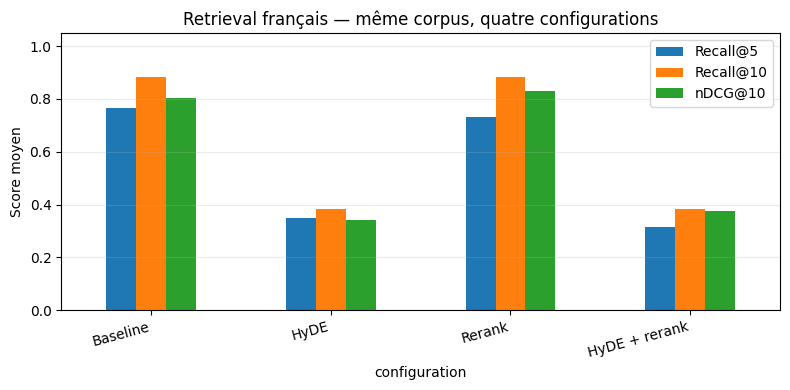

In [10]:
comparison_rows = []
for query in queries:
    if not query["in_corpus"]:
        continue
    base = results_by_query[query["id"]]["Baseline"]["ndcg@10"]
    for name in ["HyDE", "Rerank", "HyDE + rerank"]:
        score = results_by_query[query["id"]][name]["ndcg@10"]
        comparison_rows.append({
            "question": query["id"],
            "variante": name,
            "delta_nDCG": score - base,
        })

deltas = pd.DataFrame(comparison_rows)
worst = deltas.sort_values("delta_nDCG").head(5)
print("Cinq régressions les plus fortes face à la baseline :")
print(worst.to_string(index=False, formatters={"delta_nDCG": "{:+.3f}".format}))

print("\nQuestions hors corpus — le moteur retourne malgré tout un top-1 :")
for query in queries:
    if query["in_corpus"]:
        continue
    for name in ["Baseline", "HyDE + rerank"]:
        doc_id, score = results_by_query[query["id"]][name]["ranking"][0]
        print(f"  {query['id']} | {name:<14} -> {doc_id:<18} score={score:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
summary.plot(kind="bar", ylim=(0, 1.05), ax=ax)
ax.set_ylabel("Score moyen")
ax.set_title("Retrieval français — même corpus, quatre configurations")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


### Exercice 3 — Ajouter une règle d'abstention

**Objectif** : empêcher une réponse sûre d'elle-même sur une question hors corpus.

**Étapes** :
1. choisir un seuil sur le score du top-1 ou sur l'écart top-1/top-2 ;
2. calibrer le seuil sur les 20 questions in-corpus ;
3. mesurer taux d'abstention correct et faux rejets sur les 4 questions hors corpus.

> Un seuil n'est pas universel : les scores du bi-encoder et du cross-encoder n'ont pas la même échelle.


In [11]:
def should_abstain(ranking, threshold):
    # TODO étudiant : exploiter score top-1 et/ou marge top-1 moins top-2.
    return None

resultat_exercice_3 = None  # TODO étudiant : matrice de confusion abstention/réponse
print("Exercice 3 à compléter : calibrer l'abstention sur les questions hors corpus.")


Exercice 3 à compléter : calibrer l'abstention sur les questions hors corpus.


## 6. Guide de choix et coût conceptuel

| Technique | Coût principal | Gain possible | Limite structurante |
|---|---|---|---|
| Bi-encoder | encodage du corpus une fois | rappel rapide à grande échelle | interaction question-document faible |
| HyDE | une génération par question | rapproche vocabulaire requête/document | hallucination ou dérive du document hypothétique |
| Cross-encoder | un forward par candidat | meilleur ordre dans le top-k | ne récupère pas un document absent des candidats |
| HyDE + rerank | cumule les deux coûts | combine rappel et précision d'ordre | latence maximale, gain non garanti |

**Décision outillée** : commencez par mesurer la baseline. Ajoutez HyDE si le rappel souffre d'un écart de formulation ; ajoutez le reranker si les bons documents sont présents mais mal ordonnés. Si les questions hors corpus sont fréquentes, l'abstention et la couverture documentaire passent avant l'optimisation du ranking.

### Ponts avec le dépôt

- `01-Hands-On-Grounding` fournit le stockage/retrieval vectoriel ; ce notebook ajoute le protocole d'évaluation.
- `03-Embeddings-From-Scratch` explique la géométrie que le bi-encoder exploite.
- [`../Texte/5_RAG_Modern.ipynb`](../Texte/5_RAG_Modern.ipynb) construit l'application RAG complète.
- [`../PostTraining/PT_03_dpo_preferences.ipynb`](../PostTraining/PT_03_dpo_preferences.ipynb) et [`../PostTraining/PT_04_grpo_deepseek_r1.ipynb`](../PostTraining/PT_04_grpo_deepseek_r1.ipynb) montrent ensuite comment les modèles sont alignés ; ici, nous mesurons d'abord quels faits leur sont fournis.

## Conclusion

Le retrieval avancé n'est pas « HyDE + reranker » par réflexe. C'est une séquence expérimentale : **gold → baseline → variante → métriques → analyse des échecs**. Le tableau exécuté ci-dessus indique ce qui aide réellement ce corpus français ; les questions hors corpus rappellent qu'un meilleur classement ne remplace jamais une politique d'abstention.
